# Getting Data Ready for Analysis with Python in Data Frame Section

Pada pembahasan meeting 7 kita akan mempelajari 3 sub pembahasan
1. Data Cleansing
2. Data Manipulation
3. Data Wragling
4. EDA

## Koneksikan Colab dengan Drive

In [19]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## Import Packages

In [20]:
import os
import pandas as pd

## Setting Directory

In [21]:
# Inisiasi directory tempat data akan dibaca dan disimpan
path = '/content/gdrive/My Drive/PKKM KA/Day 1/Data Preparation/Data/'#silahkan masukkan path sesuai dengan letak data di drive masing-masing

In [22]:
# Cek isi direktori
os.listdir(path)

['iris.csv',
 'passenger.csv',
 'ride_sharing_new.csv',
 'sales with standardized and normalized data.csv',
 'sales.csv',
 'titanic.csv',
 'titanic2.csv']

## Load Data

In [23]:
# Load the data
df = pd.read_csv(path + 'sales.csv')

In [24]:
# Menampilkan 5 data teratas
df.head(5)

,Unnamed: 0,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2
0,0,10107,30.0,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN
1,1,10121,34.0,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN
2,2,10134,41.0,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN
3,3,10145,45.0,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN
4,4,10159,49.0,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN


## 1. Data Cleansing <br>
Data cleansing yaitu proses mendeteksi dan mengoreksi data yang rusak atau tidak akurat dari kumpulan data, tabel, atau database untuk mengidentifikasi bagian data yang tidak lengkap, tidak benar, tidak akurat atau tidak relevan. Data cleansing biasanya menghabiskan 80% waktu dalam proses menganalisa suatu data. Oleh karena itu apabila data cleaning tidak dilakukan dengan baik, maka dapat terjadi kesalah pahaman (misunderstanding) dalam menginterpretasikan suatu data. Kesalahan dari penerapan data tanpa cleansing dapat mengakibatkan kesalahan report insight data, dimana hal ini dapat menggiring kesalahan dalam mengambil keputusan. Dibawah ini merupakan ilustrasi mengapa kita perlu untuk melakukan cleaning data. <br>
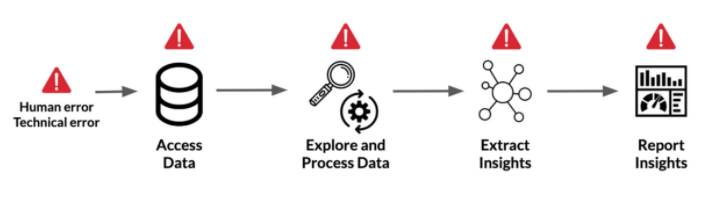

### Missing Value
Missing value merupakan kejadian yang umum terjadi ketika mengolah data dikarenakan data yang tidak tersedia sehingga terdapat beberapa data yang hilang. Missing value dapat dideteksi dengan munculnya nilai NaN (Not Available) atau blank space pada suatu tabel. Akan tetapi perlu diperhatikan juga bahwa tidak semua data yang missing disebabkan oleh kesalahan input. Terkadang terdapat kondisi dimana suatu kolom dibiarkan memiliki item yang kosong dikarenakan memang begitu adanya, misalnya terdapat data berupa fasilitas suatu rumah, dirumah tersebut tidak terdapat kolam renang, maka bisa jadi kolom kolam renang dalam data tersebut akan dikosongi. Oleh karena itu, memahami anda yang anda yang akan diolah sangat diperlukan.

In [ ]:
# Memunculkan informasi jumlah data dan tipe data tiap kolom dataset sales.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       2823 non-null   int64  
 1   ORDERNUMBER      2823 non-null   int64  
 2   QUANTITYORDERED  2821 non-null   float64
 3   PRICEEACH        2823 non-null   float64
 4   ORDERLINENUMBER  2823 non-null   int64  
 5   SALES            2823 non-null   float64
 6   ORDERDATE        2823 non-null   object 
 7   STATUS           2823 non-null   object 
 8   QTR_ID           2823 non-null   int64  
 9   MONTH_ID         2823 non-null   int64  
 10  YEAR_ID          2823 non-null   int64  
 11  PRODUCTLINE      2823 non-null   object 
 12  MSRP             2823 non-null   int64  
 13  PRODUCTCODE      2823 non-null   object 
 14  CUSTOMERNAME     2823 non-null   object 
 15  PHONE            2823 non-null   object 
 16  ADDRESSLINE1     2823 non-null   object 
 17  ADDRESSLINE2  

Dari informasi diatas diketahui bahwa terdapat perbedaan jumlah data pada masing masing kolom. Pada "Range Index" tertulis 2823 data terisi, sedangkan QUANTITYORDERED dan ADDRESSLINE2 hanya memiliki jumlah data yang kurang dari 2823. Hal tersebut mengindikasikan bahwa terdapat missing value pada kedua kolom tersebut.

In [25]:
# Mengecek berapa jumlah null value pada masing masing kolom.
jumlah_missing = pd.isnull(df).sum()
jumlah_missing

,0
Unnamed: 0,0
ORDERNUMBER,0
QUANTITYORDERED,2
PRICEEACH,0
ORDERLINENUMBER,0
SALES,0
ORDERDATE,0
STATUS,0
QTR_ID,0
MONTH_ID,0


Sebelum dilakukan cleaning data, sebaiknya kita mengetahui permasalahan apa yang terjadi pada kolom tersebut sehingga kita dapat menentukan penyelesaian apa yang sesuai dengan permasalahan missing value. <br>
Beberapa cara yang dapat dilakukan dalam mengatasi missing value, diantaranya :
1. Menghilangkan atau menghapus data yang hilang. Cara ini banyak digunakan apabila data yang kosong terlalu banyak lebih dari 60%.
2. Melakukan inputting value dengan data yang menyerupai seperti minimum value, maximum value, mean, median, atau modus. Penggunaan mean banyak digunakan apabila data tersebut adalah data kontinue, bukan kategorik data. Sedangkan modus digunakan ketika kolom yang kosong berisi informasi berupa data kategorik.
3. Melakukan manual inputting value dengan data yang sebenarnya (cara ini membutuhkan high effort untuk mencari data yang hilang tersebut)
4. Menentukan custom value berdasarkan asumsi bisnis yang terjadi.


In [26]:
# menghitung ratio missing value
rasio = jumlah_missing.div(len(df))
rasio

,0
Unnamed: 0,0.000000
ORDERNUMBER,0.000000
QUANTITYORDERED,0.000708
PRICEEACH,0.000000
ORDERLINENUMBER,0.000000
SALES,0.000000
ORDERDATE,0.000000
STATUS,0.000000
QTR_ID,0.000000
MONTH_ID,0.000000


In [27]:
# Kolom ADDRESSLINE2 memiliki jumlah missing value hingga 89% sehingga kolom ADDRESSLINE2 lebih baik dihilangkan (drop) dari table
df = df.drop(['ADDRESSLINE2'], axis=1)

In [28]:
df.head()

,Unnamed: 0,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1
0,0,10107,30.0,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue
1,1,10121,34.0,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye
2,2,10134,41.0,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia
3,3,10145,45.0,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.
4,4,10159,49.0,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.


In [29]:
# Kolom QUANTITYORDERED memiliki tipe data float64 sehingga kita harus mengetahui nilai mean dan median nya terlebih dahulu
df['QUANTITYORDERED'].describe()

,QUANTITYORDERED
count,2821.000000
mean,35.107054
std,9.734993
min,6.000000
25%,27.000000
50%,35.000000
75%,43.000000
max,97.000000


Kolom QUANTITYORDERED memiliki nilai mean dan median yang tidak terlalu jauh berbeda. Oleh karena itu permasalahan missing value pada kolom QUANTITYORDERED dapat diatasi dengan melakukan input nilai missing value dengan mean.

In [30]:
# Mengubah NaNs dengan nilai Mean
df['QUANTITYORDERED'].fillna(int(df['QUANTITYORDERED'].mean()), inplace=True)

<ipython-input-30-af36868f7c6f>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['QUANTITYORDERED'].fillna(int(df['QUANTITYORDERED'].mean()), inplace=True)


In [31]:
# Cek kembali apakah masih terdapat missing value
pd.isnull(df).sum()

,0
Unnamed: 0,0
ORDERNUMBER,0
QUANTITYORDERED,0
PRICEEACH,0
ORDERLINENUMBER,0
SALES,0
ORDERDATE,0
STATUS,0
QTR_ID,0
MONTH_ID,0


Berdasarkan pengecekan missing value, sudah tidak terdapat missing value pada data sales. Sehingga dapat dikatakan bahwa missing value telah teratasi.

### Duplicate
Duplicate issue terjadi ketika terdapat ORDERNUMBER DAN ORDERLINENUMBER yang berulang pada suatu data. Selain itu apabila suatu data memiliki informasi yang sama pada setiap kolomnya tanpa terkecuali data tersebut dianggap terduplikat.

In [32]:
# Mengidentifikasi apakah terdapat duplicate value pada tabel dengan acuan kolom ORDERNUMBER DAN ORDERLINENUMBER
df[df[["ORDERNUMBER","ORDERLINENUMBER"]].duplicated(keep=False)].sort_values("ORDERNUMBER")

,Unnamed: 0,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1
36,36,10215,35.0,100.0,3,6075.3,1/29/2004 0:00,Shipped,1,1,2004,Classic Cars,214,S10_1949,West Coast Collectables Co.,3105553722,3675 Furth Circle
370,370,10215,35.0,100.0,3,6075.3,1/29/2004 0:00,Shipped,1,1,2004,Classic Cars,214,S10_1949,West Coast Collectables Co.,3105553722,3675 Furth Circle


In [33]:
# menghilangkan duplicate value pada tabel
df = df.drop_duplicates(subset=["ORDERNUMBER","ORDERLINENUMBER"]).reset_index()

In [34]:
# Cek kembali apakah masih ada data duplicate
df[df[["ORDERNUMBER","ORDERLINENUMBER"]].duplicated(keep=False)].sort_values("ORDERNUMBER")

,index,Unnamed: 0,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2822 entries, 0 to 2821
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            2822 non-null   int64  
 1   Unnamed: 0       2822 non-null   int64  
 2   ORDERNUMBER      2822 non-null   int64  
 3   QUANTITYORDERED  2822 non-null   float64
 4   PRICEEACH        2822 non-null   float64
 5   ORDERLINENUMBER  2822 non-null   int64  
 6   SALES            2822 non-null   float64
 7   ORDERDATE        2822 non-null   object 
 8   STATUS           2822 non-null   object 
 9   QTR_ID           2822 non-null   int64  
 10  MONTH_ID         2822 non-null   int64  
 11  YEAR_ID          2822 non-null   int64  
 12  PRODUCTLINE      2822 non-null   object 
 13  MSRP             2822 non-null   int64  
 14  PRODUCTCODE      2822 non-null   object 
 15  CUSTOMERNAME     2822 non-null   object 
 16  PHONE            2822 non-null   object 
 17  ADDRESSLINE1  

Data duplikasi sudah berhasil dihapus, total baris berubah dari 2823 menjadi 2822 baris.

### Standardize and Normalize Data


Standarisasi merupakan suatu proses merubah skala data menjadi bentuk standard yang memiliki μ = 0 dan 𝛔 = 1, sehingga kita dapat membandingkan features yang memiliki skala dan unit berbeda. Proses ini digunakan apabila dalam suatu data terdapat perbedaan nilai yang cukup jauh antara satu kolom dengan kolom lainnya. Formula standarisasi sebagai berikut: <br>
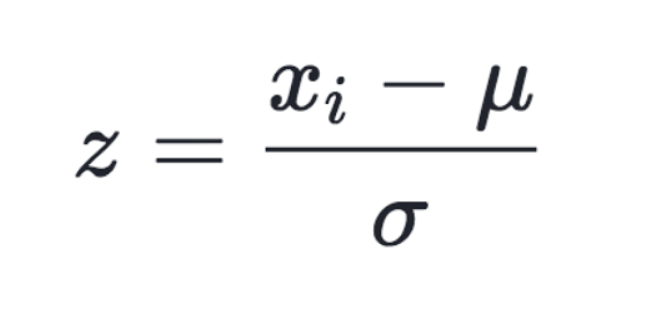

In [36]:
# Mencari tau statistika deskriptif dari kolom Fare
df["QUANTITYORDERED"].describe()

,QUANTITYORDERED
count,2822.000000
mean,35.107016
std,9.733268
min,6.000000
25%,27.000000
50%,35.000000
75%,43.000000
max,97.000000


<Axes: >

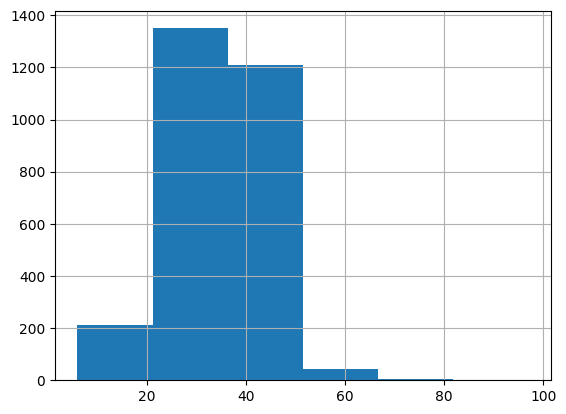

In [37]:
# Memvisualisasikan variabel Fare
df["QUANTITYORDERED"].hist(bins=6)

In [38]:
# Berdasarkan rumus yang telah diketahui, kita dapat menstandardisasi variabel QUANTITYORDERED
df['QUANTITYORDERED_stand'] = (df["QUANTITYORDERED"] - df["QUANTITYORDERED"].mean()) / (df["QUANTITYORDERED"].std())

In [39]:
# Mengecek summary statistik kolom QUANTITYORDERED_stand
df['QUANTITYORDERED_stand'].describe()

,QUANTITYORDERED_stand
count,2.822000e+03
mean,3.078095e-16
std,1.000000e+00
min,-2.990467e+00
25%,-8.329182e-01
50%,-1.099490e-02
75%,8.109284e-01
max,6.358911e+00


<Axes: >

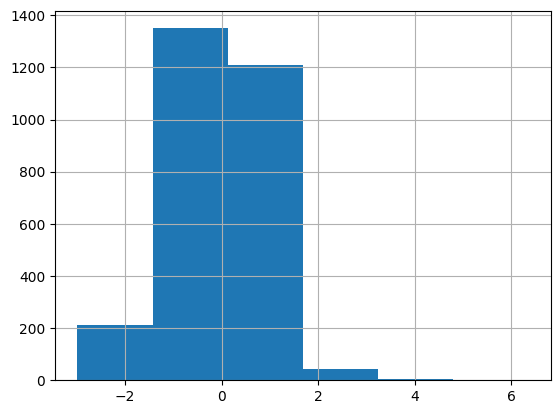

In [40]:
df['QUANTITYORDERED_stand'].hist(bins = 6)

Normalization merupakan suatu proses merubah skala nilai menjadi berdistribusi normal (Z : 0 ≤ z ≤ 1), dimana menggunakan formulasi sebagai berikut <br>

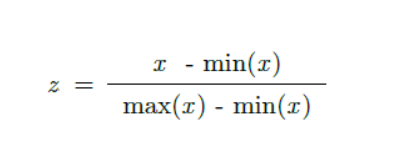

In [41]:
# Normalisasi data QUANTITYORDERED
df['QUANTITYORDERED_norm'] = (df["QUANTITYORDERED"] - df["QUANTITYORDERED"].min()) / (df["QUANTITYORDERED"].max() - df["QUANTITYORDERED"].min())

In [42]:
df["QUANTITYORDERED_norm"].describe()

,QUANTITYORDERED_norm
count,2822.000000
mean,0.319857
std,0.106959
min,0.000000
25%,0.230769
50%,0.318681
75%,0.406593
max,1.000000


In [43]:
df[['QUANTITYORDERED', 'QUANTITYORDERED_stand', 'QUANTITYORDERED_norm']].head(10)

,QUANTITYORDERED,QUANTITYORDERED_stand,QUANTITYORDERED_norm
0,30.0,-0.524697,0.263736
1,34.0,-0.113735,0.307692
2,41.0,0.605448,0.384615
3,45.0,1.016409,0.428571
4,49.0,1.427371,0.472527
5,36.0,0.091746,0.329670
6,29.0,-0.627437,0.252747
7,48.0,1.324631,0.461538
8,22.0,-1.346620,0.175824
9,41.0,0.605448,0.384615


### Export Data


In [44]:
# Data with QUANTITYORDERED standardization and Normalization
df.head(10)

,index,Unnamed: 0,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,QUANTITYORDERED_stand,QUANTITYORDERED_norm
0,0,0,10107,30.0,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,-0.524697,0.263736
1,1,1,10121,34.0,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,-0.113735,0.307692
2,2,2,10134,41.0,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,0.605448,0.384615
3,3,3,10145,45.0,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,1.016409,0.428571
4,4,4,10159,49.0,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,1.427371,0.472527
5,5,5,10168,36.0,96.66,1,3479.76,10/28/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Technics Stores Inc.,6505556809,9408 Furth Circle,0.091746,0.329670
6,6,6,10180,29.0,86.13,9,2497.77,11/11/2003 0:00,Shipped,4,11,2003,Motorcycles,95,S10_1678,Daedalus Designs Imports,20.16.1555,"184, chausse de Tournai",-0.627437,0.252747
7,7,7,10188,48.0,100.00,1,5512.32,11/18/2003 0:00,Shipped,4,11,2003,Motorcycles,95,S10_1678,Herkku Gifts,+47 2267 3215,"Drammen 121, PR 744 Sentrum",1.324631,0.461538
8,8,8,10201,22.0,98.57,2,2168.54,12/1/2003 0:00,Shipped,4,12,2003,Motorcycles,95,S10_1678,Mini Wheels Co.,6505555787,5557 North Pendale Street,-1.346620,0.175824
9,9,9,10211,41.0,100.00,14,4708.44,1/15/2004 0:00,Shipped,1,1,2004,Motorcycles,95,S10_1678,Auto Canal Petit,(1) 47.55.6555,"25, rue Lauriston",0.605448,0.384615


In [45]:
# Export Data
df.to_csv(path + 'sales with standardized and normalized data.csv')

## 2. Data Manipulation
- Check and changing data type
- Renaming
- Removing
- Filtering Dataset

### Check and change data type
Dalam data terkadang sering dijumpai kasus bahwa tipe data tidak sesuai dengan item didalamnya. Misalnya isi suatu kolom merupakan integer, namun setelah dilakukan pengecekan tipe data, ternyata hasil mengatakan bahwa kolom tersebut bertipe data string. Oleh karena itu perlu dilakukan manipulasi tipe data pada kolom tersebut.

In [46]:
# Mengecek tipe data salah satu kolom
df["QUANTITYORDERED"].dtypes

dtype('float64')

In [47]:
# Mengubah data type
df['QUANTITYORDERED_int'] = df['QUANTITYORDERED'].astype(int)

In [48]:
# Cek kembali tipe data
df["QUANTITYORDERED_int"].dtypes

dtype('int64')

In [49]:
# Cek semua tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2822 entries, 0 to 2821
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  2822 non-null   int64  
 1   Unnamed: 0             2822 non-null   int64  
 2   ORDERNUMBER            2822 non-null   int64  
 3   QUANTITYORDERED        2822 non-null   float64
 4   PRICEEACH              2822 non-null   float64
 5   ORDERLINENUMBER        2822 non-null   int64  
 6   SALES                  2822 non-null   float64
 7   ORDERDATE              2822 non-null   object 
 8   STATUS                 2822 non-null   object 
 9   QTR_ID                 2822 non-null   int64  
 10  MONTH_ID               2822 non-null   int64  
 11  YEAR_ID                2822 non-null   int64  
 12  PRODUCTLINE            2822 non-null   object 
 13  MSRP                   2822 non-null   int64  
 14  PRODUCTCODE            2822 non-null   object 
 15  CUST

### Renaming
Renaming banyak dilakukan untuk merubah nama kolom dalam suatu data. Mengubah nama kolom menjadi nama lain yang dirasa lebih sesuai atau membantu diperbolehkan.

In [50]:
df = df.rename(columns={"ORDERNUMBER": "Nomor_Pesanan",
                        "PRICEEACH": "Harga_Satuan",
                        "QUANTITYORDERED_int":"Quantity"})

In [51]:
df.head()

,index,Unnamed: 0,Nomor_Pesanan,QUANTITYORDERED,Harga_Satuan,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,...,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,QUANTITYORDERED_stand,QUANTITYORDERED_norm,Quantity
0,0,0,10107,30.0,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,...,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,-0.524697,0.263736,30
1,1,1,10121,34.0,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,...,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,-0.113735,0.307692,34
2,2,2,10134,41.0,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,...,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,0.605448,0.384615,41
3,3,3,10145,45.0,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,...,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,1.016409,0.428571,45
4,4,4,10159,49.0,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,...,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,1.427371,0.472527,49


### Removing
Removing adalah memanipulasi data dengan menghilangkan informasi-informasi yang tidak diperlukan dalam proses analisis, misalnya menghilangkan kolom atau baris dalam suatu data.

In [52]:
# Memilih beberapa kolom pada dataframe
df_fil = df[['Nomor_Pesanan', 'Quantity', 'Harga_Satuan', 'SALES','STATUS','CUSTOMERNAME']]

In [53]:
df_fil.head()

,Nomor_Pesanan,Quantity,Harga_Satuan,SALES,STATUS,CUSTOMERNAME
0,10107,30,95.70,2871.00,Shipped,Land of Toys Inc.
1,10121,34,81.35,2765.90,Shipped,Reims Collectables
2,10134,41,94.74,3884.34,Shipped,Lyon Souveniers
3,10145,45,83.26,3746.70,Shipped,Toys4GrownUps.com
4,10159,49,100.00,5205.27,Shipped,Corporate Gift Ideas Co.


In [54]:
# Menghilangkan kolom CUSTOMERNAME pada data yang akan dianalisis
df_fil_clean = df_fil.drop(['CUSTOMERNAME'], axis=1)
df_fil_clean.head()

,Nomor_Pesanan,Quantity,Harga_Satuan,SALES,STATUS
0,10107,30,95.70,2871.00,Shipped
1,10121,34,81.35,2765.90,Shipped
2,10134,41,94.74,3884.34,Shipped
3,10145,45,83.26,3746.70,Shipped
4,10159,49,100.00,5205.27,Shipped


### Filtering Dataset
Filtering dataset filtering digunakan agar hasil analisa kita dapat mengerucut ke objective atau tujuan analisis tersebut.

In [55]:
df_fil_clean.head()

,Nomor_Pesanan,Quantity,Harga_Satuan,SALES,STATUS
0,10107,30,95.70,2871.00,Shipped
1,10121,34,81.35,2765.90,Shipped
2,10134,41,94.74,3884.34,Shipped
3,10145,45,83.26,3746.70,Shipped
4,10159,49,100.00,5205.27,Shipped


In [56]:
# Memfilter 2 data pertama Nomor_Pesanan dan Status
df_fil_clean[['Nomor_Pesanan','STATUS']].iloc[0:2]

,Nomor_Pesanan,STATUS
0,10107,Shipped
1,10121,Shipped


In [57]:
# Memfilter seluruh data STATUS SHIPPED
shipped = df_fil_clean[df_fil_clean['STATUS'] == 'Shipped']

In [58]:
shipped.head()

,Nomor_Pesanan,Quantity,Harga_Satuan,SALES,STATUS
0,10107,30,95.70,2871.00,Shipped
1,10121,34,81.35,2765.90,Shipped
2,10134,41,94.74,3884.34,Shipped
3,10145,45,83.26,3746.70,Shipped
4,10159,49,100.00,5205.27,Shipped


In [59]:
# Memfilter seluruh data pesanan dengan quantity
sedikit = df_fil_clean[df_fil_clean['Quantity'] <= 10]

In [60]:
sedikit.head()

,Nomor_Pesanan,Quantity,Harga_Satuan,SALES,STATUS
315,10419,10,100.00,1092.20,Shipped
750,10409,6,100.00,785.64,Shipped
906,10423,10,88.14,881.40,In Process
1286,10407,6,90.19,541.14,On Hold


## 3. Data Wrangling
- Merging
- Grouping
- Transformation
- Data Correlation

### Merging
Merging merupakan proses penggabungan dua atau lebih tabel menjadi satu tabel agar memudahkan dalam mengolah suatu data.

In [61]:
# Kita memiliki 2 tabel, yaitu tabel quantity dan tabel sales dimana Nomor_Pesanan sebagai primary key
quantity = df_fil_clean[['Nomor_Pesanan','Quantity']]
sales = df_fil_clean[['Nomor_Pesanan','SALES']]


In [62]:
quantity.head()

,Nomor_Pesanan,Quantity
0,10107,30
1,10121,34
2,10134,41
3,10145,45
4,10159,49


In [63]:
sales.head()

,Nomor_Pesanan,SALES
0,10107,2871.00
1,10121,2765.90
2,10134,3884.34
3,10145,3746.70
4,10159,5205.27


In [64]:
# Menggabungkan tabel quantity dengan tabel sales dengan nomor pesanan menjadi key nya
df_new = quantity.merge(sales, how='left', on='Nomor_Pesanan')

In [65]:
df_new.head()

,Nomor_Pesanan,Quantity,SALES
0,10107,30,2871.00
1,10107,30,3896.49
2,10107,30,6065.55
3,10107,30,3036.60
4,10107,30,2055.23


### Grouping
Grouping dapat digunakan untuk agregasi dan mengelompokkan berdasarkan kolom tertentu.


In [66]:
df_fil_clean.groupby('STATUS')['Nomor_Pesanan'].count()

,Nomor_Pesanan
STATUS,
Cancelled,60
Disputed,14
In Process,41
On Hold,44
Resolved,47
Shipped,2616


### Transformation
Data transformation merupakan suatu proses merubah format, struktur, atau nilai dari suatu data.

In [67]:
df_fil_clean.head()

,Nomor_Pesanan,Quantity,Harga_Satuan,SALES,STATUS
0,10107,30,95.70,2871.00,Shipped
1,10121,34,81.35,2765.90,Shipped
2,10134,41,94.74,3884.34,Shipped
3,10145,45,83.26,3746.70,Shipped
4,10159,49,100.00,5205.27,Shipped


In [68]:
# Contoh penerapan fungsi transformasi x/1000 pada data Sales
df_fil_clean['SALES_transform'] = df_fil_clean['SALES'].transform(func = lambda x : x / 1000)

In [69]:
df_fil_clean.head()

,Nomor_Pesanan,Quantity,Harga_Satuan,SALES,STATUS,SALES_transform
0,10107,30,95.70,2871.00,Shipped,2.87100
1,10121,34,81.35,2765.90,Shipped,2.76590
2,10134,41,94.74,3884.34,Shipped,3.88434
3,10145,45,83.26,3746.70,Shipped,3.74670
4,10159,49,100.00,5205.27,Shipped,5.20527


### Data Correlation
Data correlation digunakan untuk mengetahui seberapa besar hubungan antara 2 variabel.
Nilai korelasi berada dalam rentang -1 hingga 1. Semakin mendekati 1 atau -1 nilai korelasinya maka semakin kuat hubungan antara 2 variabel tersebut. Nilai korelasi yang positif berarti 2 variabel tersebut memiliki hubungan searah/linier, apabila nilai salah satu variabelnya bertambah maka nilai variabel lainnya juga bertambah. Berlaku kebalikannya, Nilai korelasi yang negatif berarti 2 variabel memiliki hubungan berlawanan, pabila nilai salah satu variabelnya bertambah maka nilai variabel lainnya akan berkurang.

In [74]:
# Mencari korelasi antara kolom harga satuan dan sales
df_correlation = df_fil_clean[['Harga_Satuan','SALES']]
df_correlation.corr()

,Harga_Satuan,SALES
Harga_Satuan,1.000000,0.658207
SALES,0.658207,1.000000


<Axes: xlabel='Harga_Satuan', ylabel='SALES'>

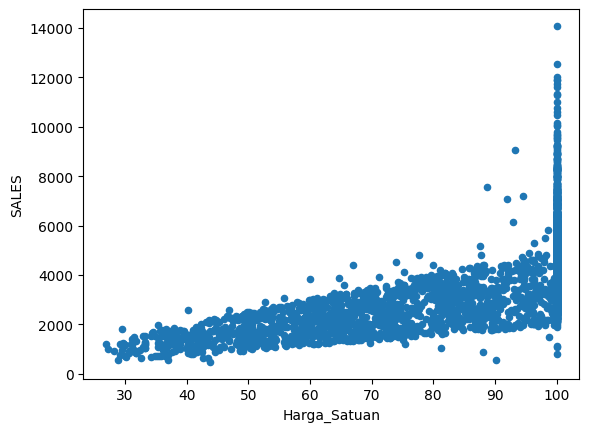

In [75]:
# Memvisualisasikan 2, Harga_Satuan dan sales untuk melihat korelasi
df_fil_clean.plot.scatter(x='Harga_Satuan', y='SALES')

In [90]:
df_fil_clean['STATUS'] = df_fil_clean['STATUS'].replace('Shipped', 1)
df_fil_clean['STATUS'] = df_fil_clean['STATUS'].replace('Disputed', 2)
df_fil_clean['STATUS'] = df_fil_clean['STATUS'].replace('In Process', 3)
df_fil_clean['STATUS'] = df_fil_clean['STATUS'].replace('Cancelled', 4)
df_fil_clean['STATUS'] = df_fil_clean['STATUS'].replace('On Hold',5)
df_fil_clean['STATUS'] = df_fil_clean['STATUS'].replace('Resolved',6)

print(df_fil_clean[df_fil_clean['STATUS'] == 1].head())



   Nomor_Pesanan  Quantity  Harga_Satuan    SALES  STATUS  SALES_transform
0          10107        30         95.70  2871.00       1          2.87100
1          10121        34         81.35  2765.90       1          2.76590
2          10134        41         94.74  3884.34       1          3.88434
3          10145        45         83.26  3746.70       1          3.74670
4          10159        49        100.00  5205.27       1          5.20527


<ipython-input-90-da6f9bf80777>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_fil_clean['STATUS'] = df_fil_clean['STATUS'].replace('Resolved',6)


In [91]:
# Mencari korelasi antar kolom pada dataset
df_fil_clean.corr()

,Nomor_Pesanan,Quantity,Harga_Satuan,SALES,STATUS,SALES_transform
Nomor_Pesanan,1.000000,0.064339,-0.002568,0.039587,0.217934,0.039587
Quantity,0.064339,1.000000,0.006753,0.551722,0.054488,0.551722
Harga_Satuan,-0.002568,0.006753,1.000000,0.658207,-0.012609,0.658207
SALES,0.039587,0.551722,0.658207,1.000000,-0.005645,1.000000
STATUS,0.217934,0.054488,-0.012609,-0.005645,1.000000,-0.005645
SALES_transform,0.039587,0.551722,0.658207,1.000000,-0.005645,1.000000


> Harga satuan dan sales memiliki hubungan yang kuat.

# Exploratory Data Analytics (EDA)

In [77]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


sns.set(style="whitegrid", font_scale=1.75)

1. Membuat chart, dengan melihat berapa banyak yang pesanan pada tiap status

In [78]:
df_fil_clean.groupby('STATUS')['Nomor_Pesanan'].count()

,Nomor_Pesanan
STATUS,
Cancelled,60
Disputed,14
In Process,41
On Hold,44
Resolved,47
Shipped,2616


<Figure size 1000x800 with 0 Axes>

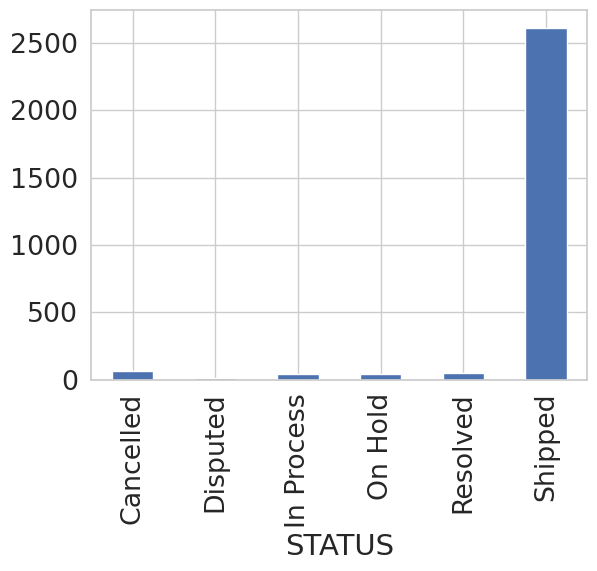

<Figure size 1000x800 with 0 Axes>

In [79]:
df_fil_clean.groupby('STATUS')['Nomor_Pesanan'].count().plot.bar()
plt.figure(figsize=(10,8))

2. Membuat chart quantitas setiap statusnya

<Figure size 1000x800 with 0 Axes>

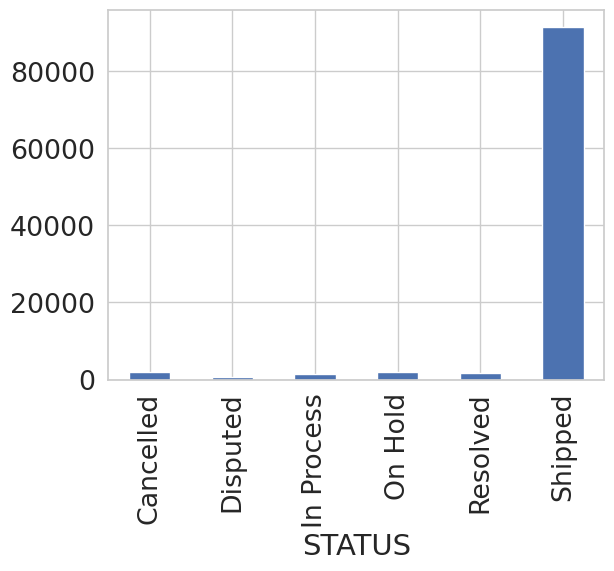

<Figure size 1000x800 with 0 Axes>

In [80]:
df_fil_clean.groupby('STATUS')['Quantity'].sum().plot.bar()
plt.figure(figsize=(10,8))

3. Membuat boxplot sales setiap statusnya

<Axes: xlabel='STATUS', ylabel='SALES'>

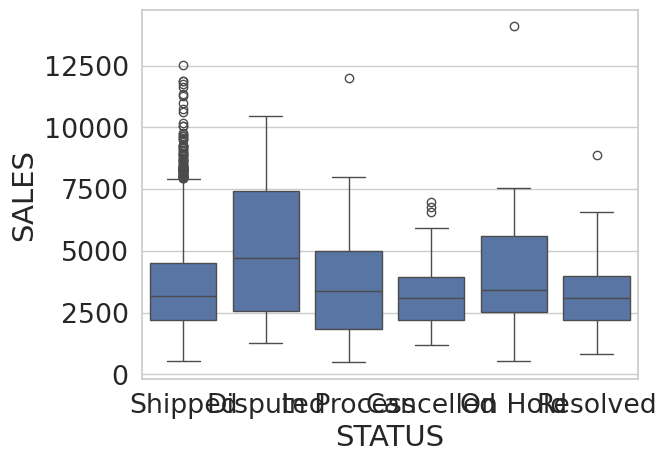

In [81]:
sns.boxplot(x="STATUS", y="SALES",data=df_fil_clean)

4. Membuat chart sales

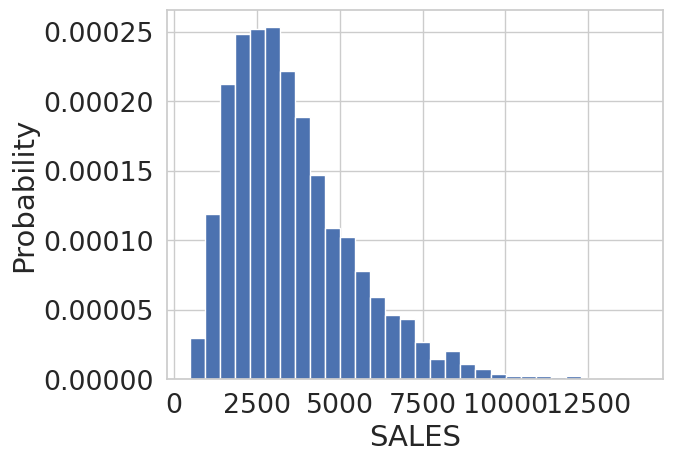

In [82]:
plt.hist(df_fil_clean['SALES'], density=True, bins=30)  # density=False would make counts
plt.ylabel('Probability')
plt.xlabel('SALES');